# `quadratic_diagonal`: worked examples and reproducibility

This notebook accompanies the repository
[`quadratic_diagonal`](https://github.com/tomaszkania/quadratic_diagonal) and
illustrates the exact API used in the paper.

The implementation is a pure-Python reference implementation intended to be
readable, testable, and easy to translate or integrate into SageMath-style
Python workflows. The notebook shows a constructive representability witness,
an explicit non-representability certificate, bounded truant output, a
surrogate generic exact baseline for comparison, and the performance plots
regenerated by `scripts/reproduce_tables.py`.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from quadratic_diagonal import (
    RealQuadraticOrder,
    diagonal_representability_dp,
    diagonal_representability_mitm,
    bounded_truants_batched,
    enumerate_weighted_search,
    benchmark_generic_baseline,
)
from IPython.display import Image, display

ROOT


PosixPath('/mnt/data/toms_final/quadratic_diagonal')

## Constructive representability witness

In [2]:
order = RealQuadraticOrder(5)
coeffs = [(1, 0), (1, 0), (1, 0)]
alpha = (15, 1)

dp_result = diagonal_representability_dp(order, coeffs, alpha)
mitm_result = diagonal_representability_mitm(order, coeffs, alpha)

print('represented (DP):', dp_result.represented)
print('roots (DP):', dp_result.roots)
print('represented (MITM):', mitm_result.represented)
print('roots (MITM):', mitm_result.roots)


represented (DP): True
roots (DP): ((0, 1), (-1, 2), (3, 0))
represented (MITM): True
roots (MITM): ((0, 1), (-1, 2), (3, 0))


## Explicit non-representability certificate

In [3]:
order = RealQuadraticOrder(21)
coeffs = [(2, 1), (1, 0), (1, 0)]
alpha = (4, 2)

search_21 = enumerate_weighted_search(order, (2, 1), alpha)
search_1 = enumerate_weighted_search(order, (1, 0), alpha)
result = diagonal_representability_dp(order, coeffs, alpha)

print('S_(2,1)(alpha):', sorted(search_21.value_to_root))
print('S_(1,0)(alpha):', sorted(search_1.value_to_root))
print('represented:', result.represented)
print('DP state counts:', result.state_counts)


S_(2,1)(alpha): [(2, 1)]
S_(1,0)(alpha): []
represented: False
DP state counts: (1, 1, 2)


## Bounded truant examples

In [4]:
for D, coeffs, B in [
    (5, [(1, 0), (1, 0), (1, 0)], 12),
    (5, [(1, 0), (1, 0), (2, 1)], 40),
    (13, [(1, 0), (2, 1), (2, 1), (1, 0)], 18),
    (21, [(2, 1), (1, 0), (1, 0)], 16),
]:
    order = RealQuadraticOrder(D)
    print(f'D={D}, coeffs={coeffs}, B={B}')
    print(bounded_truants_batched(order, coeffs, B))
    print()


D=5, coeffs=[(1, 0), (1, 0), (1, 0)], B=12
[]

D=5, coeffs=[(1, 0), (1, 0), (2, 1)], B=40
[]

D=13, coeffs=[(1, 0), (2, 1), (2, 1), (1, 0)], B=18
[(3, -1), (3, 0), (3, 2), (6, -1), (6, 3)]

D=21, coeffs=[(2, 1), (1, 0), (1, 0)], B=16
[(4, 2), (6, -2), (5, 2), (6, 0), (7, -2), (6, 2), (8, -2)]



## Performance plots

/mnt/data/toms_final/quadratic_diagonal/paper/figures/enumeration_candidates.png


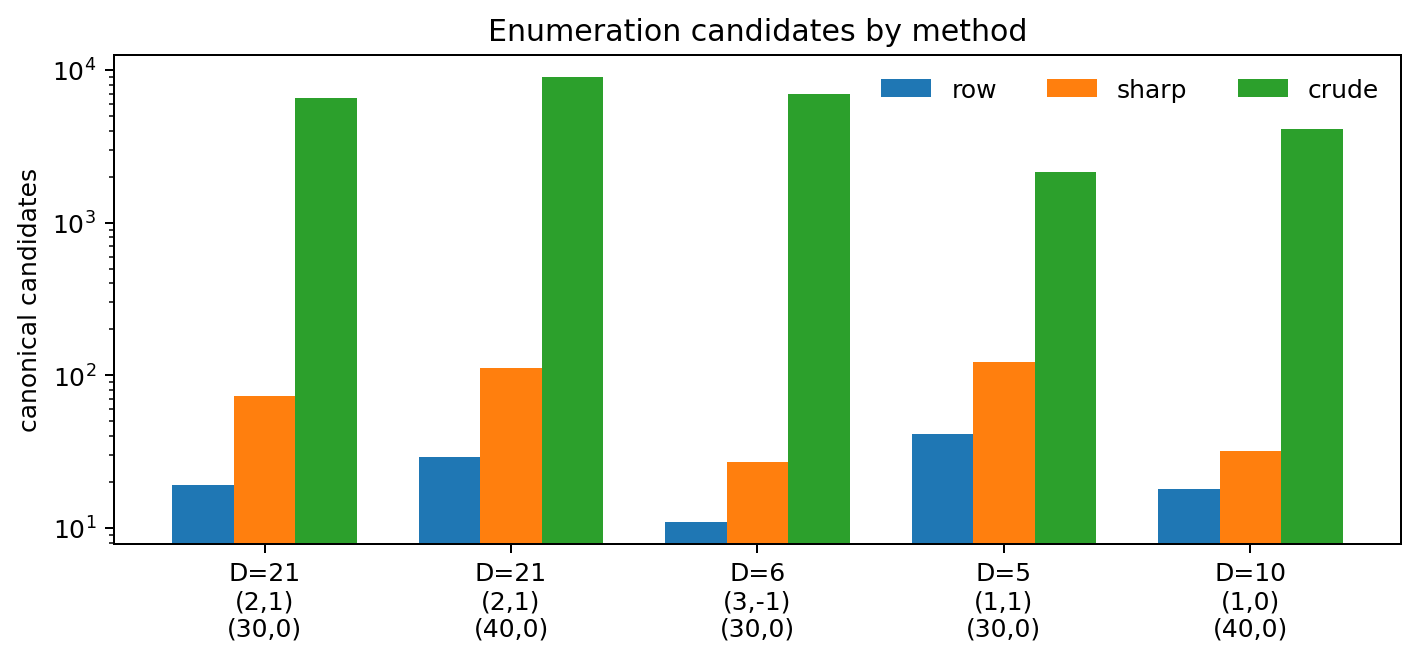

/mnt/data/toms_final/quadratic_diagonal/paper/figures/generic_baseline_runtime.png


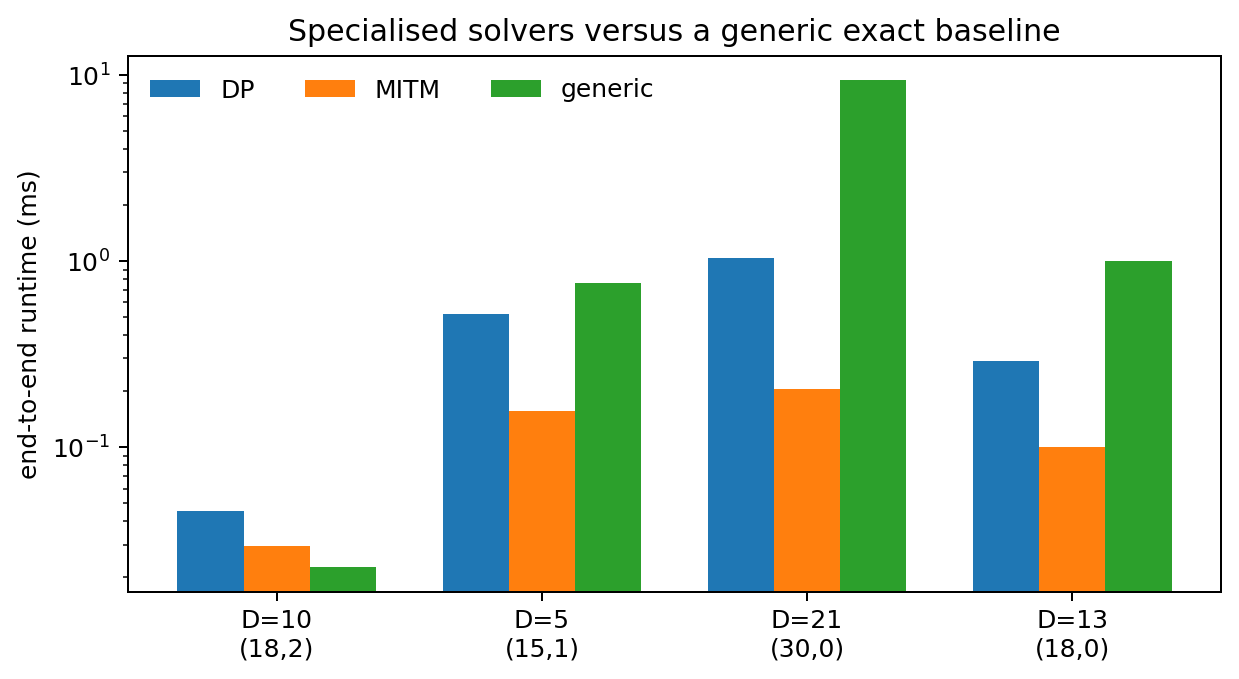

/mnt/data/toms_final/quadratic_diagonal/paper/figures/bounded_runtime.png


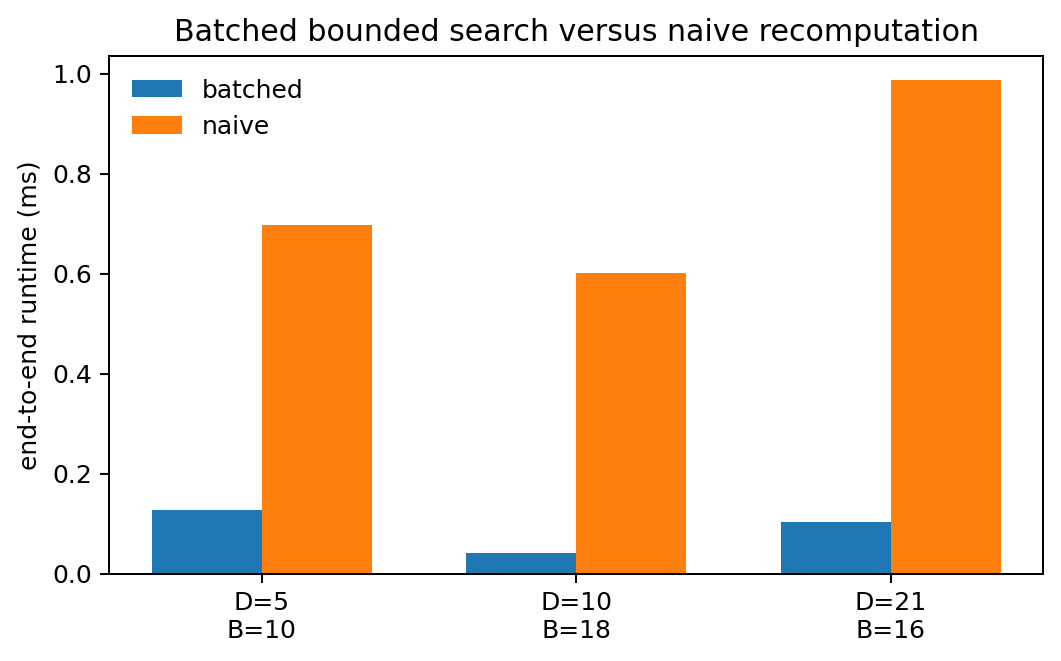

/mnt/data/toms_final/quadratic_diagonal/paper/figures/optimisation_runtime.png


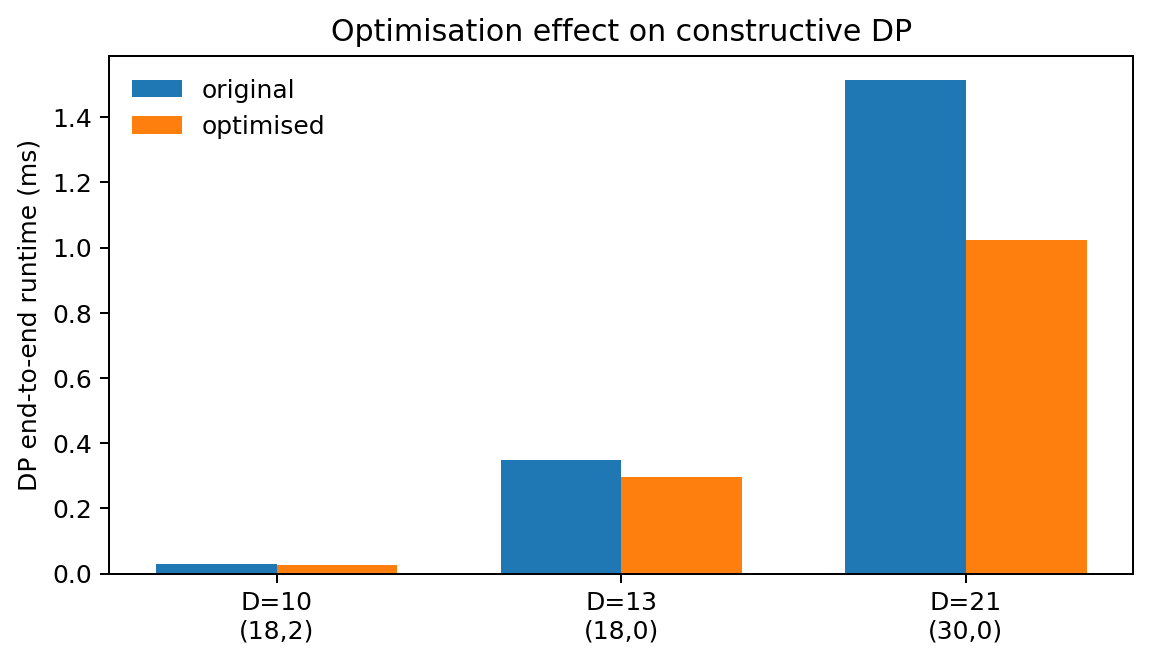

In [5]:
for name in ['enumeration_candidates.png', 'generic_baseline_runtime.png', 'bounded_runtime.png', 'optimisation_runtime.png']:
    path = ROOT / 'paper' / 'figures' / name
    print(path)
    display(Image(filename=str(path)))